# Clustering Examples

In [1]:
import numpy as np
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.datasets import make_blobs
from sklearn import metrics
from sklearn.cluster import KMeans
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn import datasets

In [ ]:
print("Reference: Dorin Comaniciu and Peter Meer, 'Mean Shift: A robust approach toward feature space analysis")
print('IEEE Transactions on Pattern Analysis and Machine Intelligence. 2002. pp. 603-619.')

Reference: Dorin Comaniciu and Peter Meer, 'Mean Shift: A robust approach toward feature space analysis
IEEE Transactions on Pattern Analysis and Machine Intelligence. 2002. pp. 603-619.


## Example 1: Clustering with Mean Shift

In [ ]:
# Generate sample data
centers = [[1, 1], [-1, -1], [1, -1]]
X, _ = make_blobs(n_samples=10000, centers=centers, cluster_std=0.6)

In [ ]:
print(X)

[[ 0.90356012  0.0327149 ]
 [ 1.30449563 -0.23329162]
 [-0.99623616 -0.27348605]
 ...
 [ 0.74391694 -1.32631918]
 [ 1.77362588 -0.07705936]
 [ 0.71167053  0.86132086]]


In [ ]:
# Train the model and determine the number of clusters
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=500)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)
labels = ms.labels_
cluster_centers = ms.cluster_centers_
labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)
print("number of estimated clusters : %d" % n_clusters_)

number of estimated clusters : 3


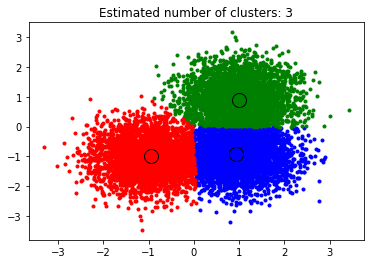

In [ ]:
# Plot result
%matplotlib inline
import matplotlib.pyplot as plt
from itertools import cycle
plt.figure(1)
plt.clf()
colors = cycle('bgrcmykbgrcmykbgrcmykbgrcmyk')
for k, col in zip(range(n_clusters_), colors):
  my_members = labels == k
  cluster_center = cluster_centers[k]
  plt.plot(X[my_members, 0], X[my_members, 1], col + '.')
  plt.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,
           markeredgecolor='k', markersize=14)
plt.title('Estimated number of clusters: %d' % n_clusters_)
plt.show()

## Example 2: Clustering with K-Means

In [ ]:
## Train and evaluate the model
kmeans_model = KMeans(n_clusters=3, random_state=1).fit(X)
labels = kmeans_model.labels_
metrics.silhouette_score(X, labels, metric='euclidean')

0.494766604175246

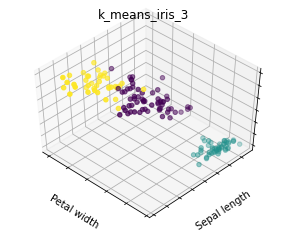

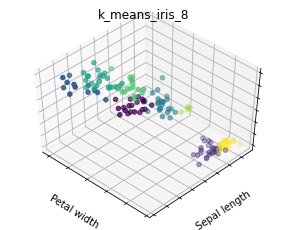

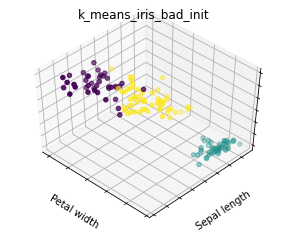

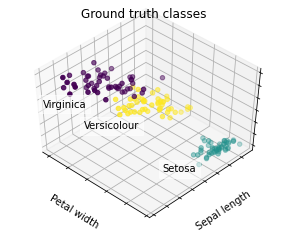

In [ ]:
np.random.seed(5)

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Define different K-Means clustering models
estimators = {'k_means_iris_3': KMeans(n_clusters=3),
              'k_means_iris_8': KMeans(n_clusters=8),
              'k_means_iris_bad_init': KMeans(n_clusters=3, n_init=1,
                                              init='random')}

# Train the different models and plot the results
fignum = 1
for name, est in estimators.items():
  fig = plt.figure(fignum, figsize=(4, 3))
  plt.clf()
  ax = Axes3D(fig, rect=[0, 0, .95, 1], elev=48, azim=134)
  plt.cla()
  est.fit(X)
  labels = est.labels_
  ax.scatter(X[:, 3], X[:, 0], X[:, 2], c=labels.astype(np.float))
  ax.w_xaxis.set_ticklabels([])
  ax.w_yaxis.set_ticklabels([])
  ax.w_zaxis.set_ticklabels([])
  ax.set_xlabel('Petal width')
  ax.set_ylabel('Sepal length')
  ax.set_zlabel('Petal length')
  plt.title(name)
  fignum = fignum + 1

# Plot the ground truth
fig = plt.figure(fignum, figsize=(4, 3))
plt.clf()
ax = Axes3D(fig, rect=[0, 0, .95, 1], elev=48, azim=134)
plt.cla()
plt.title('Ground truth classes')
for name, label in [('Setosa', 0),
                    ('Versicolour', 1),
                    ('Virginica', 2)]:
  ax.text3D(X[y == label, 3].mean(),
  X[y == label, 0].mean() + 1.5,
  X[y == label, 2].mean(), name,
  horizontalalignment='center',
  bbox=dict(alpha=.5, edgecolor='w', facecolor='w'))

# Reorder the labels to have colors matching the cluster results
y = np.choose(y, [1, 2, 0]).astype(np.float)
ax.scatter(X[:, 3], X[:, 0], X[:, 2], c=y)
ax.w_xaxis.set_ticklabels([])
ax.w_yaxis.set_ticklabels([])
ax.w_zaxis.set_ticklabels([])
ax.set_xlabel('Petal width')
ax.set_ylabel('Sepal length')
ax.set_zlabel('Petal length')
plt.show()